# Exploración inicial: Outliers del estudio general

## Objetivo:
Identificar los jugadores que vayan en contra de la corriente moderna de evitar los lanzamientos a media distancia en pro de hacerlos todos de triple o bajo el aro.
Se buscarán estos jugadores y se analizará el por qué.

## Criterios para identificarlos:
Descartar jugadores que hayan jugado pocos minutos.
Descartar jugadores con porcentaje bajo de éxito al intentar encestar desde media distancia.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players
import pandas as pd

In [ ]:
# Para cumplir con el criterio, revisamos la documentación y extraemos un df de todos los lanzamientos.
# La documentación de esta tabla en particular sería: https://github.com/swar/nba_api/blob/master/docs/nba_api/stats/endpoints/shotchartdetail.md 
# FGA son los intentos de lanzamiento, con acierto o no.
# FGM serían todos los aciertos. Podríamos filtrar ahora mismo, pero prefiero hacerlo más tarde para calcular porcentajes.

df_shots = shotchartdetail.ShotChartDetail(
    team_id=0,
    player_id=0,
    context_measure_simple="FGA",
    season_nullable="2024-25",  # Si pongo solo 2025 me lanza también parte de 2026 y pierdo datos. Prefiero usar los de la temporada completa, con playoffs y todo.
    season_type_all_star="Regular Season"
).get_data_frames()[0]

df_shots

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,0022400001,7,1642258,Zaccharie Risacher,1610612737,Atlanta Hawks,1,11,43,...,Left Side Center(LC),24+ ft.,26,-168,205,1,0,20241112,BOS,ATL
1,Shot Chart Detail,0022400001,10,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,11,38,...,Left Side(L),8-16 ft.,13,-136,-1,1,0,20241112,BOS,ATL
2,Shot Chart Detail,0022400001,12,1628401,Derrick White,1610612738,Boston Celtics,1,11,24,...,Left Side Center(LC),24+ ft.,28,-181,218,1,0,20241112,BOS,ATL
3,Shot Chart Detail,0022400001,21,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,10,50,...,Right Side Center(RC),24+ ft.,25,157,203,1,1,20241112,BOS,ATL
4,Shot Chart Detail,0022400001,23,1627759,Jaylen Brown,1610612738,Boston Celtics,1,10,35,...,Right Side Center(RC),24+ ft.,27,102,253,1,1,20241112,BOS,ATL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219522,Shot Chart Detail,0022401230,705,1630578,Alperen Sengun,1610612745,Houston Rockets,4,0,47,...,Center(C),24+ ft.,25,-29,257,1,0,20241214,OKC,HOU
219523,Shot Chart Detail,0022401230,707,1627832,Fred VanVleet,1610612745,Houston Rockets,4,0,42,...,Left Side(L),24+ ft.,22,-228,-17,1,0,20241214,OKC,HOU
219524,Shot Chart Detail,0022401230,715,1629652,Luguentz Dort,1610612760,Oklahoma City Thunder,4,0,24,...,Right Side Center(RC),24+ ft.,24,186,167,1,1,20241214,OKC,HOU
219525,Shot Chart Detail,0022401230,719,1630224,Jalen Green,1610612745,Houston Rockets,4,0,13,...,Center(C),Less Than 8 ft.,2,12,16,1,1,20241214,OKC,HOU


In [ ]:
# Aquí la revisión de antes. Pillamos solo las 4 primeras "letras", que corresponden al año y vemos que sacamos La temporada completa.
df_shots["GAME_DATE"].str[:4].value_counts()

GAME_DATE
2025    133592
2024     85935
Name: count, dtype: int64

In [4]:
# Aunque me guste mucho verlo en el Data Wrangler, voy a ponerlo por aquí.
df_shots.columns.tolist()

['GRID_TYPE',
 'GAME_ID',
 'GAME_EVENT_ID',
 'PLAYER_ID',
 'PLAYER_NAME',
 'TEAM_ID',
 'TEAM_NAME',
 'PERIOD',
 'MINUTES_REMAINING',
 'SECONDS_REMAINING',
 'EVENT_TYPE',
 'ACTION_TYPE',
 'SHOT_TYPE',
 'SHOT_ZONE_BASIC',
 'SHOT_ZONE_AREA',
 'SHOT_ZONE_RANGE',
 'SHOT_DISTANCE',
 'LOC_X',
 'LOC_Y',
 'SHOT_ATTEMPTED_FLAG',
 'SHOT_MADE_FLAG',
 'GAME_DATE',
 'HTM',
 'VTM']

In [ ]:
# SHOT_ZONE_BASIC es la que tiene el dato que nos interesa para el estudio.
# De aquí partimos para filtrar el mid-range
# Se ve nuevamente que es la zona desde donde menos se lanza, quitando backcourt, que es tirar desde tu propia zona. Desde medio campo para atrás.
# Los de esquina tampoco deberían contar mucho porque son lanzamientos de 3 desde los laterales del área. En esencia, lo mismo que uno de 3.
df_shots["SHOT_ZONE_BASIC"].value_counts()

SHOT_ZONE_BASIC
Above the Break 3        68358
Restricted Area          61190
In The Paint (Non-RA)    44475
Mid-Range                21402
Left Corner 3            12188
Right Corner 3           11397
Backcourt                  517
Name: count, dtype: int64

In [ ]:
# Aquí ya nos quedamos con los lanzamientos de Mid-Range y podemos operar bastante
df_mid = df_shots[df_shots["SHOT_ZONE_BASIC"] == "Mid-Range"]

df_mid

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
1,Shot Chart Detail,0022400001,10,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,11,38,...,Left Side(L),8-16 ft.,13,-136,-1,1,0,20241112,BOS,ATL
22,Shot Chart Detail,0022400001,84,1628369,Jayson Tatum,1610612738,Boston Celtics,1,6,44,...,Left Side(L),16-24 ft.,16,-152,50,1,0,20241112,BOS,ATL
41,Shot Chart Detail,0022400001,163,1630700,Dyson Daniels,1610612737,Atlanta Hawks,1,1,11,...,Right Side(R),8-16 ft.,12,110,57,1,1,20241112,BOS,ATL
75,Shot Chart Detail,0022400001,290,1630811,Keaton Wallace,1610612737,Atlanta Hawks,2,4,17,...,Left Side(L),8-16 ft.,9,-87,46,1,0,20241112,BOS,ATL
83,Shot Chart Detail,0022400001,317,1628401,Derrick White,1610612738,Boston Celtics,2,2,15,...,Center(C),8-16 ft.,15,4,154,1,1,20241112,BOS,ATL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219476,Shot Chart Detail,0022401230,487,1628415,Dillon Brooks,1610612745,Houston Rockets,3,2,18,...,Right Side(R),8-16 ft.,13,136,-5,1,0,20241214,OKC,HOU
219485,Shot Chart Detail,0022401230,547,1641708,Amen Thompson,1610612745,Houston Rockets,4,11,14,...,Center(C),8-16 ft.,14,2,148,1,0,20241214,OKC,HOU
219494,Shot Chart Detail,0022401230,592,1630198,Isaiah Joe,1610612760,Oklahoma City Thunder,4,8,25,...,Left Side(L),8-16 ft.,14,-114,90,1,1,20241214,OKC,HOU
219504,Shot Chart Detail,0022401230,638,1631095,Jabari Smith Jr.,1610612745,Houston Rockets,4,5,44,...,Left Side(L),8-16 ft.,12,-123,-8,1,1,20241214,OKC,HOU


In [7]:
# Primero el FGA: Los intentos desde mid-range
# Agrupamos por jugador y así estudiamos más adelante
mid_fga = df_mid.groupby(["PLAYER_ID", "PLAYER_NAME"])["SHOT_ATTEMPTED_FLAG"].sum().reset_index()
mid_fga

,PLAYER_ID,PLAYER_NAME,SHOT_ATTEMPTED_FLAG
0,2544,LeBron James,218
1,101108,Chris Paul,130
2,200768,Kyle Lowry,9
3,200782,P.J. Tucker,1
4,201142,Kevin Durant,286
...,...,...,...
509,1642419,Jamison Battle,22
510,1642461,Spencer Jones,2
511,1642484,RayJ Dennis,2
512,1642505,Alex Ducas,2


In [8]:
# Segundo el FGM, que son los aciertos
# De nuevo, por jugador también

mid_fgm = df_mid.groupby(["PLAYER_ID", "PLAYER_NAME"])["SHOT_MADE_FLAG"].sum().reset_index()
mid_fgm

,PLAYER_ID,PLAYER_NAME,SHOT_MADE_FLAG
0,2544,LeBron James,95
1,101108,Chris Paul,61
2,200768,Kyle Lowry,3
3,200782,P.J. Tucker,0
4,201142,Kevin Durant,152
...,...,...,...
509,1642419,Jamison Battle,10
510,1642461,Spencer Jones,1
511,1642484,RayJ Dennis,2
512,1642505,Alex Ducas,1


In [ ]:
# Todo a un solo df
# Por si algún profesor lee esto: Busqué hacerlo con el join, pero el join trabaja sobre el índice y, para no liarme mucho
# usé el merge. Espero que no haga cosas extrañas el merge. Confío en que no.

# Pero antes le voy a cambiar el nombre a las dos columnas para que se vea mejor lo de FGA y FGM
mid_fga = mid_fga.rename(columns={"SHOT_ATTEMPTED_FLAG": "MID_FGA"})
mid_fgm = mid_fgm.rename(columns={"SHOT_MADE_FLAG": "MID_FGM"})

df_mid_stats = mid_fga.merge(mid_fgm, on=["PLAYER_ID", "PLAYER_NAME"])

df_mid_stats

,PLAYER_ID,PLAYER_NAME,MID_FGA,MID_FGM
0,2544,LeBron James,218,95
1,101108,Chris Paul,130,61
2,200768,Kyle Lowry,9,3
3,200782,P.J. Tucker,1,0
4,201142,Kevin Durant,286,152
...,...,...,...,...
509,1642419,Jamison Battle,22,10
510,1642461,Spencer Jones,2,1
511,1642484,RayJ Dennis,2,2
512,1642505,Alex Ducas,2,1


In [10]:
# Me interesa sacar los porcentajes, como ya dije arriba
df_mid_stats["MID_FG_%"] = round(df_mid_stats["MID_FGM"] / df_mid_stats["MID_FGA"] * 100, 2)

df_mid_stats.sort_values("MID_FGA", ascending=False)

,PLAYER_ID,PLAYER_NAME,MID_FGA,MID_FGM,MID_FG_%
16,201942,DeMar DeRozan,640,293,45.78
157,1628983,Shai Gilgeous-Alexander,348,174,50.00
83,1626164,Devin Booker,325,168,51.69
4,201142,Kevin Durant,286,152,53.15
52,203507,Giannis Antetokounmpo,283,125,44.17
...,...,...,...,...,...
458,1641817,Anton Watson,1,1,100.00
466,1641989,Elijah Harkless,1,0,0.00
464,1641879,Yuri Collins,1,1,100.00
3,200782,P.J. Tucker,1,0,0.00


In [ ]:
# Los nombres ya me empiezan a sonar y eso que no soy muy aficionado a la NBA
# Añadimos otra columna más que será el porcentaje de lanzamientos totales que son mid-rage
# Nos interesan los que tengan muchos a mid-rage, los "outliers" de verdad en la moda esta

fga_total = df_shots.groupby(["PLAYER_ID", "PLAYER_NAME"])["SHOT_ATTEMPTED_FLAG"].sum().reset_index()
fga_total = fga_total.rename(columns={"SHOT_ATTEMPTED_FLAG": "FGA_TOTAL"})

# De nuevo mergeo con df_mid_stats
df_mid_stats = df_mid_stats.merge(fga_total, on=["PLAYER_ID", "PLAYER_NAME"])

# Columna de porcentaje de los que son de mid-range
df_mid_stats["MID_RATE_%"] = round(df_mid_stats["MID_FGA"] / df_mid_stats["FGA_TOTAL"] * 100, 2)

In [ ]:
df_mid_stats.sort_values("MID_FGA", ascending=False)

,PLAYER_ID,PLAYER_NAME,MID_FGA,MID_FGM,MID_FG_%,FGA_TOTAL,MID_RATE_%
16,201942,DeMar DeRozan,640,293,45.78,1308,48.93
157,1628983,Shai Gilgeous-Alexander,348,174,50.00,1656,21.01
83,1626164,Devin Booker,325,168,51.69,1420,22.89
4,201142,Kevin Durant,286,152,53.15,1124,25.44
52,203507,Giannis Antetokounmpo,283,125,44.17,1319,21.46
...,...,...,...,...,...,...,...
458,1641817,Anton Watson,1,1,100.00,9,11.11
466,1641989,Elijah Harkless,1,0,0.00,35,2.86
464,1641879,Yuri Collins,1,1,100.00,3,33.33
3,200782,P.J. Tucker,1,0,0.00,7,14.29


In [ ]:
df_mid_stats.sort_values("MID_RATE_%", ascending=False)

,PLAYER_ID,PLAYER_NAME,MID_FGA,MID_FGM,MID_FG_%,FGA_TOTAL,MID_RATE_%
181,1629056,Terence Davis,1,0,0.00,2,50.00
16,201942,DeMar DeRozan,640,293,45.78,1308,48.93
464,1641879,Yuri Collins,1,1,100.00,3,33.33
100,1627742,Brandon Ingram,101,46,45.54,333,30.33
43,203114,Khris Middleton,101,51,50.50,337,29.97
...,...,...,...,...,...,...,...
263,1630231,KJ Martin,1,1,100.00,201,0.50
359,1631117,Walker Kessler,2,0,0.00,419,0.48
173,1629021,Moritz Wagner,1,0,0.00,249,0.40
434,1641739,Toumani Camara,2,0,0.00,716,0.28


In [ ]:
# En la celda anterior se observan jugadores no relevantes para lo que queremos estudiar
# Terence Davis con dos lanzamientos y uno de ellos a mid-range... no es interesante. Así un montón.
# Hora de limpiar todo eso
# Para eso voy a calcular la mediana de lanzamientos totales y luego usar ese número para decidir quién entra en la lista de relevantes y quién no
# Al final estamos buscando jugadores fuera de serie
# Lo siento mucho por el resto. Seguro que jugaron muy bien.

df_mid_stats["FGA_TOTAL"].describe()

count     514.000000
mean      424.099222
std       354.853680
min         2.000000
25%       125.250000
50%       338.000000
75%       613.000000
max      1656.000000
Name: FGA_TOTAL, dtype: float64

In [ ]:
# La mediana de lanzamientos totales es de 338. Quiero algo un poquito más allá, sean jugadores notorios, así que
# a medio camino entre el percentil 75% me quedo con 400 para hacer el filtro de jugadores relevantes
# Recuerdo: Esto es filtrar por el número de lanzamientos totales

df_mid_relevantes = df_mid_stats[df_mid_stats["FGA_TOTAL"] >= 400]

df_mid_relevantes.sort_values("MID_RATE_%", ascending=False)

,PLAYER_ID,PLAYER_NAME,MID_FGA,MID_FGM,MID_FG_%,FGA_TOTAL,MID_RATE_%
16,201942,DeMar DeRozan,640,293,45.78,1308,48.93
87,1626171,Bobby Portis,170,71,41.76,595,28.57
22,202331,Paul George,155,65,41.94,570,27.19
4,201142,Kevin Durant,286,152,53.15,1124,25.44
104,1627750,Jamal Murray,278,125,44.96,1121,24.80
...,...,...,...,...,...,...,...
235,1630168,Onyeka Okongwu,5,3,60.00,684,0.73
115,1627827,Dorian Finney-Smith,3,2,66.67,435,0.69
350,1631105,Jalen Duren,3,3,100.00,546,0.55
359,1631117,Walker Kessler,2,0,0.00,419,0.48


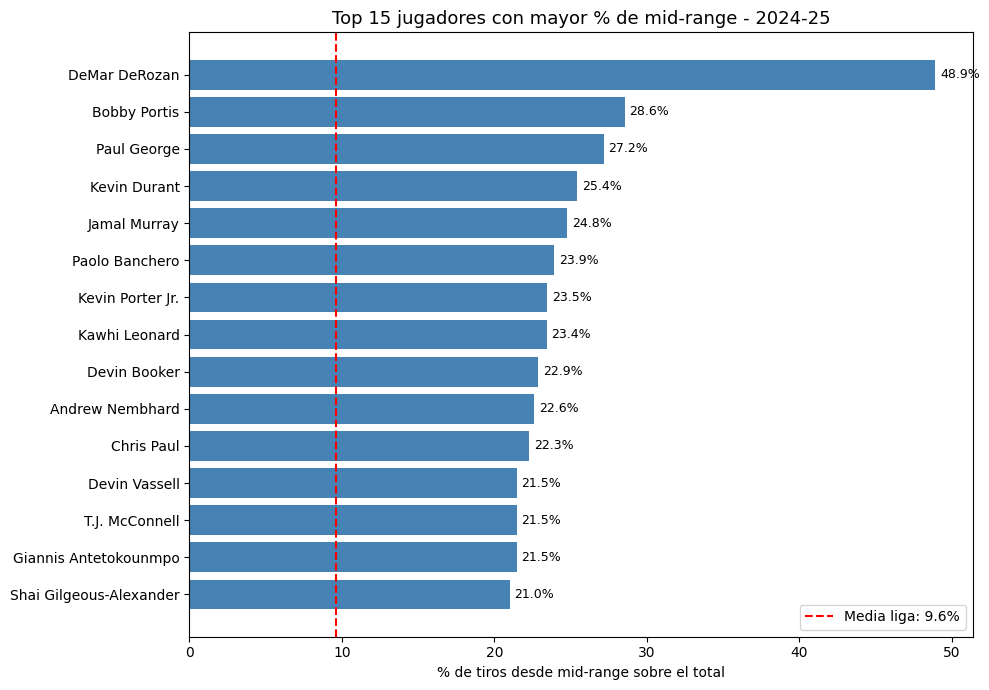

In [ ]:
# VISUALIZACIÓN

top15 = df_mid_relevantes.sort_values("MID_RATE_%", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(top15["PLAYER_NAME"], top15["MID_RATE_%"], color="steelblue")

media = df_mid_relevantes["MID_RATE_%"].mean()
ax.axvline(media, color="red", linestyle="--", label=f"Media liga: {media:.1f}%")

for bar, val in zip(bars, top15["MID_RATE_%"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_xlabel("% de tiros desde mid-range sobre el total")
ax.set_title("Top 15 jugadores con mayor % de mid-range - 2024-25", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("top15_volumen_midrange.png")
plt.show()

Queda clarísimo con el gráfico.  
Ahora bien, esto no es lo que buscamos del todo porque esto no significa que acierten.  
Vamos a visualizar nuestro estudio después de sacar los "verdaderos outliers".  

In [ ]:
media_rate = df_mid_relevantes["MID_RATE_%"].mean()
media_fg = df_mid_relevantes["MID_FG_%"].mean()

outliers = df_mid_relevantes[(df_mid_relevantes["MID_RATE_%"] > media_rate) &
    (df_mid_relevantes["MID_FG_%"] > media_fg)].sort_values("MID_RATE_%", ascending=False)

# Ordeno las columnas así porque salen desordenadas y no es tan intuitivo de ver
# No conozco otro método
outliers[["PLAYER_NAME", "MID_FGA", "MID_FGM", "MID_FG_%", "MID_RATE_%", "FGA_TOTAL"]]

,PLAYER_NAME,MID_FGA,MID_FGM,MID_FG_%,MID_RATE_%,FGA_TOTAL
16,DeMar DeRozan,640,293,45.78,48.93,1308
87,Bobby Portis,170,71,41.76,28.57,595
22,Paul George,155,65,41.94,27.19,570
4,Kevin Durant,286,152,53.15,25.44,1124
104,Jamal Murray,278,125,44.96,24.80,1121
...,...,...,...,...,...,...
506,Jaylen Wells,66,27,40.91,9.76,676
56,Jordan Clarkson,48,19,39.58,9.74,493
245,Jaden McDaniels,81,34,41.98,9.71,834
123,Malik Monk,91,37,40.66,9.69,939


In [ ]:
# Vemos la distribución otra vez para hacer un proceso parecido al anterior
df_mid_relevantes["MID_FGA"].describe()

count    232.000000
mean      78.793103
std       75.689731
min        2.000000
25%       27.750000
50%       56.000000
75%      106.250000
max      640.000000
Name: MID_FGA, dtype: float64

In [ ]:
# El percentil 75% está en 106
# Voy a usar ese para marcar los realmente excepcionales

df_mid_top = df_mid_relevantes[df_mid_relevantes["MID_FGA"] >= 106]\
    .sort_values("MID_FG_%", ascending=False)

df_mid_top[["PLAYER_NAME", "MID_FGA", "MID_FGM", "MID_FG_%", "MID_RATE_%", "FGA_TOTAL"]]

,PLAYER_NAME,MID_FGA,MID_FGM,MID_FG_%,MID_RATE_%,FGA_TOTAL
4,Kevin Durant,286,152,53.15,25.44,1124
73,Nikola Jokić,116,60,51.72,8.50,1364
83,Devin Booker,325,168,51.69,22.89,1420
149,Mikal Bridges,211,107,50.71,17.84,1183
15,Stephen Curry,130,65,50.00,10.33,1258
157,Shai Gilgeous-Alexander,348,174,50.00,21.01,1656
259,Desmond Bane,117,58,49.57,11.49,1018
236,Tyrese Haliburton,155,75,48.39,15.41,1006
30,Kawhi Leonard,146,70,47.95,23.43,623
38,Damian Lillard,165,79,47.88,16.63,992


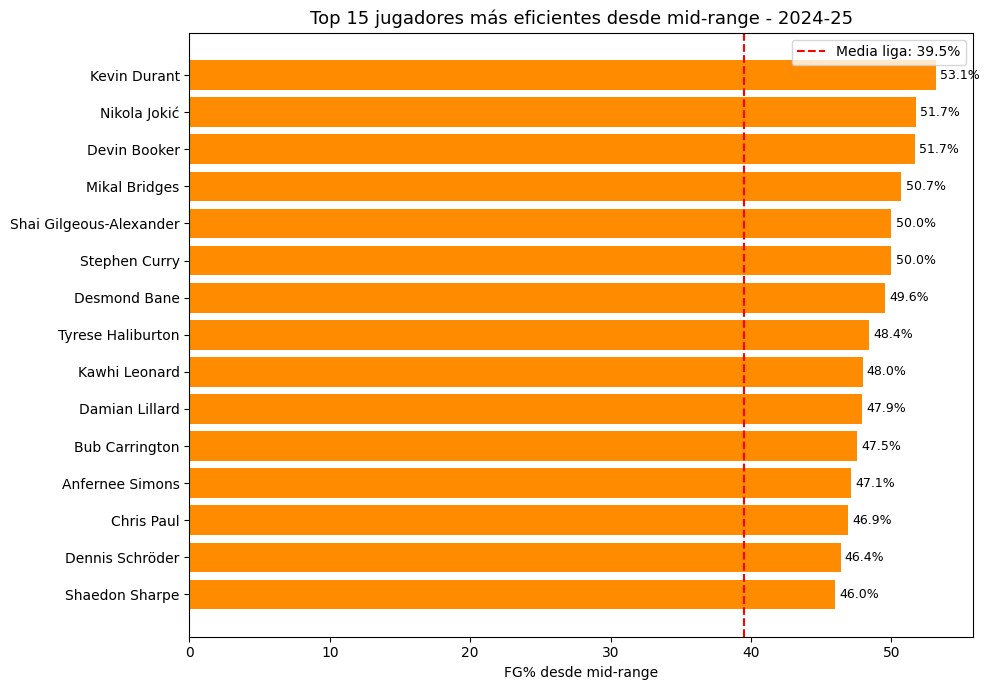

In [ ]:
# VISUALIZACIÓN

top15_eficiencia = df_mid_top.sort_values("MID_FG_%", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(top15_eficiencia["PLAYER_NAME"], top15_eficiencia["MID_FG_%"], color="darkorange")

media_fg = df_mid_relevantes["MID_FG_%"].mean()
ax.axvline(media_fg, color="red", linestyle="--", label=f"Media liga: {media_fg:.1f}%")

for bar, val in zip(bars, top15_eficiencia["MID_FG_%"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_xlabel("FG% desde mid-range")
ax.set_title("Top 15 jugadores más eficientes desde mid-range - 2024-25", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

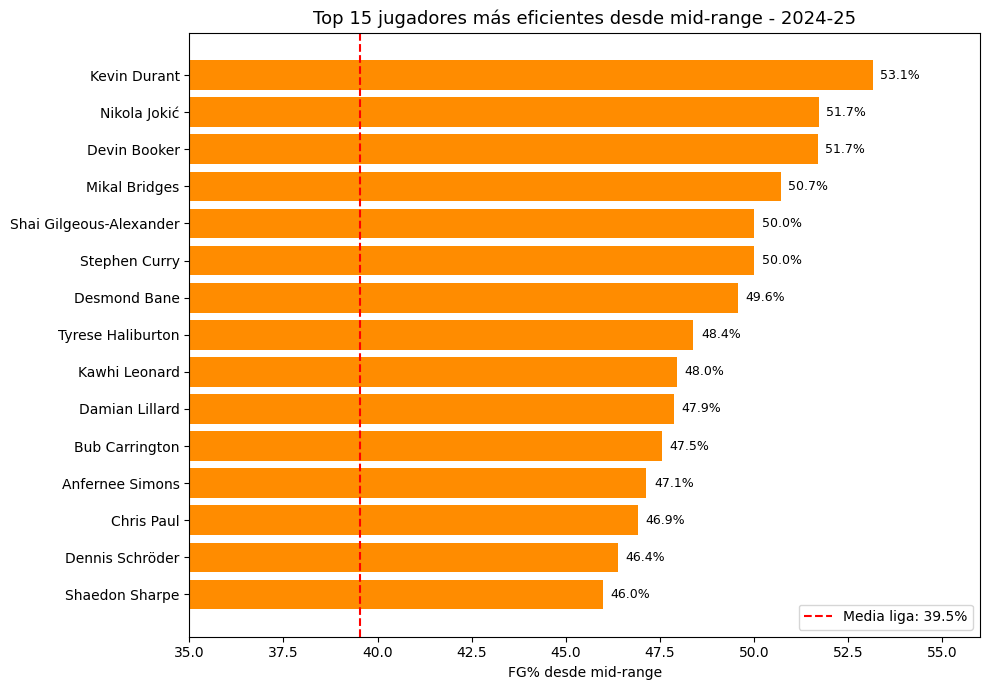

In [ ]:
# CORRECCIÓN PARA QUE SE VEA MUCHO MEJOR

top15_eficiencia = df_mid_top.sort_values("MID_FG_%", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(top15_eficiencia["PLAYER_NAME"], top15_eficiencia["MID_FG_%"], color="darkorange")

media_fg = df_mid_relevantes["MID_FG_%"].mean()
ax.axvline(media_fg, color="red", linestyle="--", label=f"Media liga: {media_fg:.1f}%")

for bar, val in zip(bars, top15_eficiencia["MID_FG_%"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_xlim(35, 56)  # Para que la visualización sea algo más bonita: Empezamos desde aquí y no desde el cero
ax.set_xlabel("FG% desde mid-range")
ax.set_title("Top 15 jugadores más eficientes desde mid-range - 2024-25", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("top15_eficientes_mid-range.png")
plt.show()

## Primeras conclusiones

El análisis de los 219.527 tiros de la temporada 2024-25 nos permite identificar los jugadores que van contra la tendencia moderna de la NBA.

**Jugadores que más apuestan por el mid-range** (con mínimo de 400 lanzamientos en toda la temporada)

![Volumen mid-range](top15_volumen_midrange.png)

**Jugadores más eficientes desde mid-range** (con un mínimo 106 intentos):

![Eficiencia mid-range](top15_eficientes_mid-range.png)

Los jugadores que destacan en la segunda gráfica son los candidatos para el Notebook 2:  
**Kevin Durant,**  
**Nikola Jokic,**  
**Devin Booker**  
**Mikal Bridges**.